## Analysing performance of different uncertainty quantifiers across different correctness criterina

#### 1. Importing relevant libraries

In [1]:
import json
from math import exp
import numpy as np
import math
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

#### 2. Read relevant files

In [ ]:
def read_inputs(path_results, path_annotations):
    with open(path_results, "r") as f:
        results = json.load(f)

    with open(path_annotations, "r") as f:
        annotations = json.load(f)
    return results, annotations

In [ ]:
# Trivia QA - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-8b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-8b-instruct_annotations_new.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Llama 8B - Annotator 2
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-8b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-8b-instruct-2nd-annotator.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_llama-3b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_qwen-7b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_qwen-7b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Trivia QA - Qwen 0.5B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/trivia_qa_qwen-0.5b-instruct.json"
# path_annotations = "/auroc_eval/results/annotations/trivia_qa_qwen-0.5b-instruct_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# ------------------------------------------------------------------------------------------------

# Ambig QA (single answer) - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_llama-8b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_llama-3b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_qwen-7b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_qwen-7b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (single answer) - Qwen 0.5B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_single_answer_qwen-0.5b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_single_answer_qwen-0.5b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# ------------------------------------------------------------------------------------------------

# Ambig QA (multiple answers) - Llama 8B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-8b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 8B - Annotator 2
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-8b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-8b-instruct_100_0_annotations-2nd-annotator.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 3B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_llama-3b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_llama-3b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Qwen 7B - Annotator 1
# path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_qwen-7b-instruct_100_0.json"
# path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_qwen-7b-instruct_100_0_annotations.json"
# results, annotations = read_inputs(path_results, path_annotations)

# Ambig QA (multiple answers) - Llama 8B - Annotator 1
path_results = "/auroc_eval/results/uncertainty_quantifiers/ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0.json"
path_annotations = "/auroc_eval/results/annotations/ambig_qa_multiple_qas_qwen-0.5b-instruct_100_0_annotations.json"
results, annotations = read_inputs(path_results, path_annotations)

In [264]:
model_name = path_results.split("/")[-1].replace(".json", "")

#### 3. Analyse AUROC values across quantifiers based on different quality metrics

In [268]:
def compute_auroc(score, correctness):
    """
    Compute AUROC for a given score and correctness labels
    
    Args: 
        score: list of float, scores of the uncertainty quantifiers
        correctness: list of int, correctness labels (0 or 1)
        
    Returns:
        auroc: float, AUROC value
    """
    roc_auc = roc_auc_score(correctness, score)
    return roc_auc    
    

In [269]:
def extract_correctness(results):
    correctness = [r["greedy_correctness"]["correctness"] for r in results]
    exact_match_correctness = [x["exact_match"] for x in correctness]
    try:
        llm_as_judge_correctness = [x["llm_as_judge"] for x in correctness]
    except:
        llm_as_judge_correctness_os = [x["llm_as_judge_llama-8b-instruct"] for x in correctness]
        llm_as_judge_correctness_api = [x["llm_as_judge_gpt-5.4-mini"] for x in correctness]

        try:
            llm_as_judge_correctness_os_small = [x["llm_as_judge_qwen-0.5b-instruct"] for x in correctness]
        except:
            pass

    token_f1 = {}
    for x in correctness:
        for k in x["token_f1"]:
            try: 
                token_f1[k].append(x["token_f1"][k])
            except:
                token_f1[k] = [x["token_f1"][k]]
    
    bleu = {}
    for x in correctness:
        for k in x["bleu"]:
            try:
                bleu[k].append(x["bleu"][k])
            except:
                bleu[k] = [x["bleu"][k]]
    
    rouge_l = {}
    for x in correctness:
        for k in x["rouge_l"]:
            try:
                rouge_l[k].append(x["rouge_l"][k])
            except:
                rouge_l[k] = [x["rouge_l"][k]]
    
    embedding_similarity = {}
    for x in correctness:
        for k in x["embedding_similarity"]:
            try:
                embedding_similarity[k].append(x["embedding_similarity"][k])
            except:
                embedding_similarity[k] = [x["embedding_similarity"][k]]
    
    bert_score = {}
    for x in correctness:
        for k in x["bert_score"]:
            try:
                bert_score[k].append(x["bert_score"][k])
            except:
                bert_score[k] = [x["bert_score"][k]]

    try:
        return exact_match_correctness, llm_as_judge_correctness, token_f1, bleu, rouge_l, embedding_similarity, bert_score
    except:
        return exact_match_correctness, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score
    
def extract_uncertainty_scores(results):
    uncertainty_scores = [r["uncertainty_scores_greedy"]["uncertainty_scores"] for r in results]
    entropy_scores = [x["entropy"] for x in uncertainty_scores]
    semantic_entropy_scores = [x["semantic_entropy"] for x in uncertainty_scores]
    semantic_confidence_scores = [x["semantic_confidence"] for x in uncertainty_scores]
    prob_sequence_scores = [exp(x["log_likelihood_seq"]) for x in uncertainty_scores]
    prob_avg_token_scores = [exp(x["log_likelihood_token"]) for x in uncertainty_scores]
    prob_true_scores = [exp(x["p_true"]) for x in uncertainty_scores]
    verbalised_confidence_scores = [x["verbalised_confidence"] for x in uncertainty_scores]
    return entropy_scores, semantic_entropy_scores, semantic_confidence_scores, prob_sequence_scores, prob_avg_token_scores, prob_true_scores, verbalised_confidence_scores



In [270]:
qids = [r["question_id"] for r in results]

In [ ]:
exact_match_correctness, llm_as_judge_correctness_os, llm_as_judge_correctness_api, token_f1, bleu, rouge_l, embedding_similarity, bert_score = extract_correctness(results)
entropy_scores, semantic_entropy_scores, semantic_confidence_scores, prob_sequence_scores, prob_avg_token_scores, prob_true_scores, verbalised_confidence_scores = extract_uncertainty_scores(results)

In [ ]:
correctness = {"exact_match_correctness":exact_match_correctness,
                "llm_as_judge_correctness_os":llm_as_judge_correctness_os,
                "llm_as_judge_correctness_api":llm_as_judge_correctness_api}

for k in token_f1.keys():
    correctness[f"token_f1_{k}"] = token_f1[k]

for k in bleu.keys():
    correctness[f"bleu_{k}"] = bleu[k]

for k in rouge_l.keys():
    correctness[f"rouge_l_{k}"] = rouge_l[k]

for k in embedding_similarity.keys():
    correctness[f"embedding_similarity_{k}"] = embedding_similarity[k]

for k in bert_score.keys():
    correctness[f"bert_score_{k}"] = bert_score[k]

In [273]:
unc_scores = {"entropy_scores":entropy_scores,
              "semantic_entropy_scores":semantic_entropy_scores,
              "semantic_confidence_scores":semantic_confidence_scores,
              "prob_sequence_scores":prob_sequence_scores,
              "prob_avg_token_scores":prob_avg_token_scores,
              "prob_true_scores":prob_true_scores,
              "verbalised_confidence_scores":[float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores]}

In [ ]:
correctness_manual = [annotations[qid]["human_greedy_label"] for qid in qids]
correctness_manual = [1 if x == "correct" else 0 for x in correctness_manual]

In [ ]:
print("Actual AUROC Scores")
actual_entropy =  compute_auroc([-x for x in entropy_scores], correctness_manual)#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_entropy = compute_auroc([-x for x in semantic_entropy_scores], correctness_manual)#uncertainty - not confidence -> need to switch correctness sign
actual_semantic_confidence = compute_auroc(semantic_confidence_scores, correctness_manual)
actual_prob_sequence = compute_auroc(prob_sequence_scores, correctness_manual)
actual_prob_avg_token = compute_auroc(prob_avg_token_scores, correctness_manual)
actual_prob_true = compute_auroc(prob_true_scores, correctness_manual)
actual_verbalised_confidence = compute_auroc([float(x.replace("Confidence: ", "")) for x in verbalised_confidence_scores], correctness_manual)

scores = [('entropy', actual_entropy), ('semantic_entropy', actual_semantic_entropy), ('semantic_confidence', actual_semantic_confidence), ('prob_sequence', actual_prob_sequence), ('prob_avg_token', actual_prob_avg_token), ('prob_true', actual_prob_true), ('verbalised_confidence', actual_verbalised_confidence)]
scores.sort(key=lambda x: x[1], reverse=True)

scores


Actual AUROC Scores


[('semantic_confidence', 0.709106984969054),
 ('prob_true', 0.607869142351901),
 ('semantic_entropy', 0.5994694960212201),
 ('prob_avg_token', 0.5950486295313882),
 ('prob_sequence', 0.5163572060123784),
 ('verbalised_confidence', 0.5119363395225464),
 ('entropy', 0.5)]

In [276]:
from scipy.stats import spearmanr, kendalltau

In [277]:
data_saver = []
for c in correctness.keys():
    info = {}
    info["judge"] = c
    correct = correctness[c]
    if (sum(correct) == 0) or (sum(correct) == len(correct)):
        pass
    else:
        info["f1_score"] = f1_score(correctness_manual, correct)

        aurocs = []
        for k in unc_scores.keys():
            uq = unc_scores[k]
            auroc = roc_auc_score(correct, uq)
            aurocs.append((k, auroc))
        aurocs.sort(key=lambda x: x[1], reverse=True)
        
        info["auroc_rankings"] = aurocs
        data_saver.append(info)

final_dict = {"metadata":{"experiment":model_name, "human_rankings":scores}}
# data_saver

human_rankings = []
map_rank = {}
for i, conf in enumerate(scores):
    map_rank[conf[0]] = i+1
    human_rankings.append(map_rank[conf[0]])

for d in data_saver:
    rankings_uq = []
    for conf in d["auroc_rankings"]:
        rankings_uq.append(map_rank[conf[0].replace("_scores", "")])
    d["judge_rankings"] = rankings_uq
    d["rank_correlation_spearman"] = {"spearmanr":spearmanr(human_rankings, rankings_uq)[0], "pvalue":spearmanr(human_rankings, rankings_uq)[1]}
    d["rank_correlation_kendall"] = {"kendalltau":kendalltau(human_rankings, rankings_uq)[0], "pvalue":kendalltau(human_rankings, rankings_uq)[1]}

final_dict["data"] = data_saver

In [ ]:
with open(f"/auroc_eval/results/rank_correlations/rank-correlations-{model_name}.json", "w") as f:
    json.dump(final_dict, f)


In [ ]:
# Quantifier ranked best by AUROC (best)
best_auroc = scores[0][1]
best_auroc_metric = scores[0][0]

# Quantifier ranked fourth by AUROC (medium)
good_auroc = scores[3][1]
good_auroc_metric = scores[3][0]

# Quantifier ranked last by AUROC (worst)
worst_auroc = scores[-1][1]
worst_auroc_metric = scores[-1][0]

print(f"Best AUROC: {best_auroc} ({best_auroc_metric})")
print(f"Good AUROC: {good_auroc} ({good_auroc_metric})")
print(f"Worst AUROC: {worst_auroc} ({worst_auroc_metric})")

Best AUROC: 0.6837761674718197 (prob_true)
Good AUROC: 0.6525764895330112 (prob_avg_token)
Worst AUROC: 0.570048309178744 (entropy)


#### Analysis of AUROC values, their drops and rankings.

In [12]:
aurocs = {}

for c in correctness.keys():
    if len(set(correctness[c])) == 1:
        continue
    else:
        aurocs[c] = {} 
        aurocs[c]["metrics"] = {}
        aurocs[c]["metrics"]["acc"] = accuracy_score(correctness_manual, correctness[c])
        aurocs[c]["metrics"]["prec"] = precision_score(correctness_manual, correctness[c])
        aurocs[c]["metrics"]["rec"] = recall_score(correctness_manual, correctness[c])
        aurocs[c]["metrics"]["f1"] = f1_score(correctness_manual, correctness[c])
        aurocs[c]["metrics"]["conf_matrix"] = confusion_matrix(correctness_manual, correctness[c])

        aurocs[c]["uncertainty_metrics"] = {}
        for u in unc_scores.keys():
            if "entropy" in u:
                aurocs[c]["uncertainty_metrics"][u] = compute_auroc(unc_scores[u], [not x for x in correctness[c]])
            else:
                aurocs[c]["uncertainty_metrics"][u] = compute_auroc(unc_scores[u], correctness[c])



In [ ]:
# # Visualise AUROC of uncertainty metrics across correctness criteria

rows = []
for correctness_name, values in aurocs.items():
    for unc_name, auroc_val in values["uncertainty_metrics"].items():
        rows.append(
            {
                "correctness": correctness_name,
                "uncertainty_metric": unc_name,
                "auroc": auroc_val,
            }
        )

# Add ACTUAL uncertainty scores based on human-labelled correctness
rows.extend(
    [
        {"correctness": "manual", "uncertainty_metric": "entropy_scores", "auroc": actual_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_entropy_scores", "auroc": actual_semantic_entropy},
        {"correctness": "manual", "uncertainty_metric": "semantic_confidence_scores", "auroc": actual_semantic_confidence},
        {"correctness": "manual", "uncertainty_metric": "prob_sequence_scores", "auroc": actual_prob_sequence},
        {"correctness": "manual", "uncertainty_metric": "prob_avg_token_scores", "auroc": actual_prob_avg_token},
        {"correctness": "manual", "uncertainty_metric": "prob_true_scores", "auroc": actual_prob_true},
        {"correctness": "manual", "uncertainty_metric": "verbalised_confidence_scores", "auroc": actual_verbalised_confidence},
    ]
)

auroc_df = pd.DataFrame(rows)

In [ ]:
threshold_bad = 0.3
threshold_good = 0.7

In [ ]:
bins = np.linspace(0, 1, 11)
bins_f1 = {}
quality_correctness_metrics = {"good":[], "bad":[], "medium":[]}

for k in aurocs.keys():
    f1 = aurocs[k]["metrics"]["f1"]


    f1_bin = math.floor(f1 * 10) / 10
    try:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"].append(k)
    except:
        bins_f1[f"{f1_bin}-{f1_bin+0.1}"] = [k]

    if f1 < threshold_bad:
        quality_correctness_metrics["bad"].append(k)
    elif (f1 >= threshold_bad) and (threshold_good < 0.7):
        quality_correctness_metrics["medium"].append(k)
    else:
        quality_correctness_metrics["good"].append(k)

visual_correctness_criteria = []
for k in bins_f1.keys():
    visual_correctness_criteria.append((k,random.sample(bins_f1[k], 1)[0]))

In [47]:
filtered_aurocs = {}
for k in aurocs.keys():
    if k in visual_correctness_criteria:
        filtered_aurocs[k] = aurocs[k]

In [48]:
unique_correctness = auroc_df["correctness"].unique()

dict_f1_filtered = {}
pairs = []
for corr in unique_correctness:
    if corr == "manual":
        dict_f1_filtered[corr] = 1
        pairs.append((corr, 1))
    else:
        dict_f1_filtered[corr] = round(aurocs[corr]["metrics"]["f1"],2)
        pairs.append((corr, round(aurocs[corr]["metrics"]["f1"],2)))

In [49]:
pairs.sort(key=lambda x: x[1], reverse=False)

In [50]:
unique_correctness = np.array([x[0] for x in pairs])

In [52]:
auroc_df["auroc_rank"] = (
    auroc_df.groupby("correctness")["auroc"]
      .rank(method="first", ascending=False)
      .astype(int)
)

In [ ]:
print(best_auroc_metric)
print(best_auroc)
best_quantifier_values = auroc_df[auroc_df["uncertainty_metric"] == best_auroc_metric + '_scores']

bq_gm = best_quantifier_values[best_quantifier_values["correctness"].isin(quality_correctness_metrics["good"])]
# print(bq_gm["auroc_rank"].mean()) #Average ranking of best quantifier when good judges are used to automate correctness
print(bq_gm["auroc"].mean() - best_auroc) #Drop/increase in AUROC of best quantifier when good judges are used to automate correctness

bq_mm = best_quantifier_values[best_quantifier_values["correctness"].isin(quality_correctness_metrics["medium"])]
# print(bq_mm["auroc_rank"].mean()) #Average ranking of best quantifier when medium judges are used to automate correctness
print(bq_mm["auroc"].mean() - best_auroc) #Drop/increase in AUROC of best quantifier when medium judges are used to automate correctness

bq_bm = best_quantifier_values[best_quantifier_values["correctness"].isin(quality_correctness_metrics["bad"])]
# print(bq_bm["auroc_rank"].mean()) #Average ranking of best quantifier when bad judges are used to automate correctness
print(bq_bm["auroc"].mean() - best_auroc) #Drop/increase in AUROC of best quantifier when bad judges are used to automate correctness

# quality_correctness_metrics["good"]

prob_true
0.7938368055555556
-0.05713076834398123
-0.17394902307285687
-0.36876553934721823


In [ ]:
print(good_auroc_metric)
print(good_auroc)
good_quantifier_values = auroc_df[auroc_df["uncertainty_metric"] == good_auroc_metric + '_scores']

bq_gm = good_quantifier_values[good_quantifier_values["correctness"].isin(quality_correctness_metrics["good"])]
# print(bq_gm["auroc_rank"].mean()) #Average ranking of medium quantifier when good judges are used to automate correctness
print(bq_gm["auroc"].mean() - good_auroc) #Drop/increase in AUROC of medium quantifier when good judges are used to automate correctness

bq_mm = good_quantifier_values[good_quantifier_values["correctness"].isin(quality_correctness_metrics["medium"])]
# print(bq_mm["auroc_rank"].mean()) #Average ranking of medium quantifier when medium judges are used to automate correctness
print(bq_mm["auroc"].mean() - good_auroc) #Drop/increase in AUROC of medium quantifier when medium judges are used to automate correctness

bq_bm = good_quantifier_values[good_quantifier_values["correctness"].isin(quality_correctness_metrics["bad"])]
# print(bq_bm["auroc_rank"].mean()) #Average ranking of medium quantifier when bad judges are used to automate correctness
print(bq_bm["auroc"].mean() - good_auroc) #Drop/increase in AUROC of medium quantifier when bad judges are used to automate correctness

semantic_confidence
0.6790364583333334
-0.1447682808627686
-0.10127383886347785
-0.12109738887297639


In [ ]:
print(worst_auroc_metric)
print(worst_auroc)

worst_quantifier_values = auroc_df[auroc_df["uncertainty_metric"] == worst_auroc_metric + '_scores']

bq_gm = worst_quantifier_values[worst_quantifier_values["correctness"].isin(quality_correctness_metrics["good"])]
# print(bq_gm["auroc_rank"].mean()) #Average ranking of worst quantifier when good judges are used to automate correctness
print(bq_gm["auroc"].mean() - worst_auroc) #Drop/increase in AUROC of worst quantifier when good judges are used to automate correctness

bq_mm = worst_quantifier_values[worst_quantifier_values["correctness"].isin(quality_correctness_metrics["medium"])]
# print(bq_mm["auroc_rank"].mean()) #Average ranking of worst quantifier when medium judges are used to automate correctness
print(bq_mm["auroc"].mean() - worst_auroc) #Drop/increase in AUROC of worst quantifier when medium judges are used to automate correctness

bq_bm = worst_quantifier_values[worst_quantifier_values["correctness"].isin(quality_correctness_metrics["bad"])]
# print(bq_bm["auroc_rank"].mean()) #Average ranking of worst quantifier when bad judges are used to automate correctness
print(bq_bm["auroc"].mean() - worst_auroc) #Drop/increase in AUROC of worst quantifier when bad judges are used to automate correctness


entropy
0.5453559027777778
0.005868002763318891
0.004497612882894297
0.08091345706570507


In [56]:
# model_name = path_results.split("/")[-1].replace(".json", "")
model_name = path_annotations.split("/")[-1].replace(".json", "")
model_name

'ambig_qa_multiple_qas_llama-8b-instruct_100_0_annotations'

In [57]:
UNCERTAINTY_LABELS = {
    "entropy_scores": "Ent.",
    "semantic_entropy_scores": "Sem. entropy",
    "semantic_confidence_scores": "Sem. conf.",
    "prob_sequence_scores": "P(seq.)",
    "prob_avg_token_scores": "N.P(seq.)",
    "prob_true_scores": "P(true)",
    "verbalised_confidence_scores": "Verb. conf.",
}


def format_correctness_label(name):
    if name == "manual":
        return "Human labels"
    if name == "exact_match_correctness":
        return "Exact match"
    if name == "llm_as_judge_correctness_os":
        return "LLM judge (Llama 8B)"
    if name == "llm_as_judge_correctness_api":
        return "LLM judge (GPT)"
    if name == "llm_as_judge_correctness":
        return "LLM judge"
    if name.startswith("token_f1_"):
        return f"Token F1 (τ={name.removeprefix('token_f1_')})"
    if name.startswith("bleu_"):
        return f"BLEU (τ={name.removeprefix('bleu_')})"
    if name.startswith("rouge_l_"):
        return f"ROUGE-L (τ={name.removeprefix('rouge_l_')})"
    if name.startswith("embedding_similarity_"):
        return f"Emb. sim. (τ={name.removeprefix('embedding_similarity_')})"
    if name.startswith("bert_score_"):
        return f"BERTScore (τ={name.removeprefix('bert_score_')})"
    return name.replace("_", " ").title()


def label_heatmap_data(data):
    labelled = data.copy()
    labelled.index = [
        f"{format_correctness_label(idx)} · F1={dict_f1_filtered[idx]:.2f}"
        for idx in labelled.index
    ]
    labelled.columns = [UNCERTAINTY_LABELS.get(col, col) for col in labelled.columns]
    return labelled


def style_heatmap_axes(ax, xlabel, ylabel, title):
    ax.set_title(title, fontsize=25, pad=12)
    ax.set_xlabel(xlabel, fontsize=25, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=25, labelpad=10)
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=25,
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=25)
    ax.tick_params(axis="both", length=0)

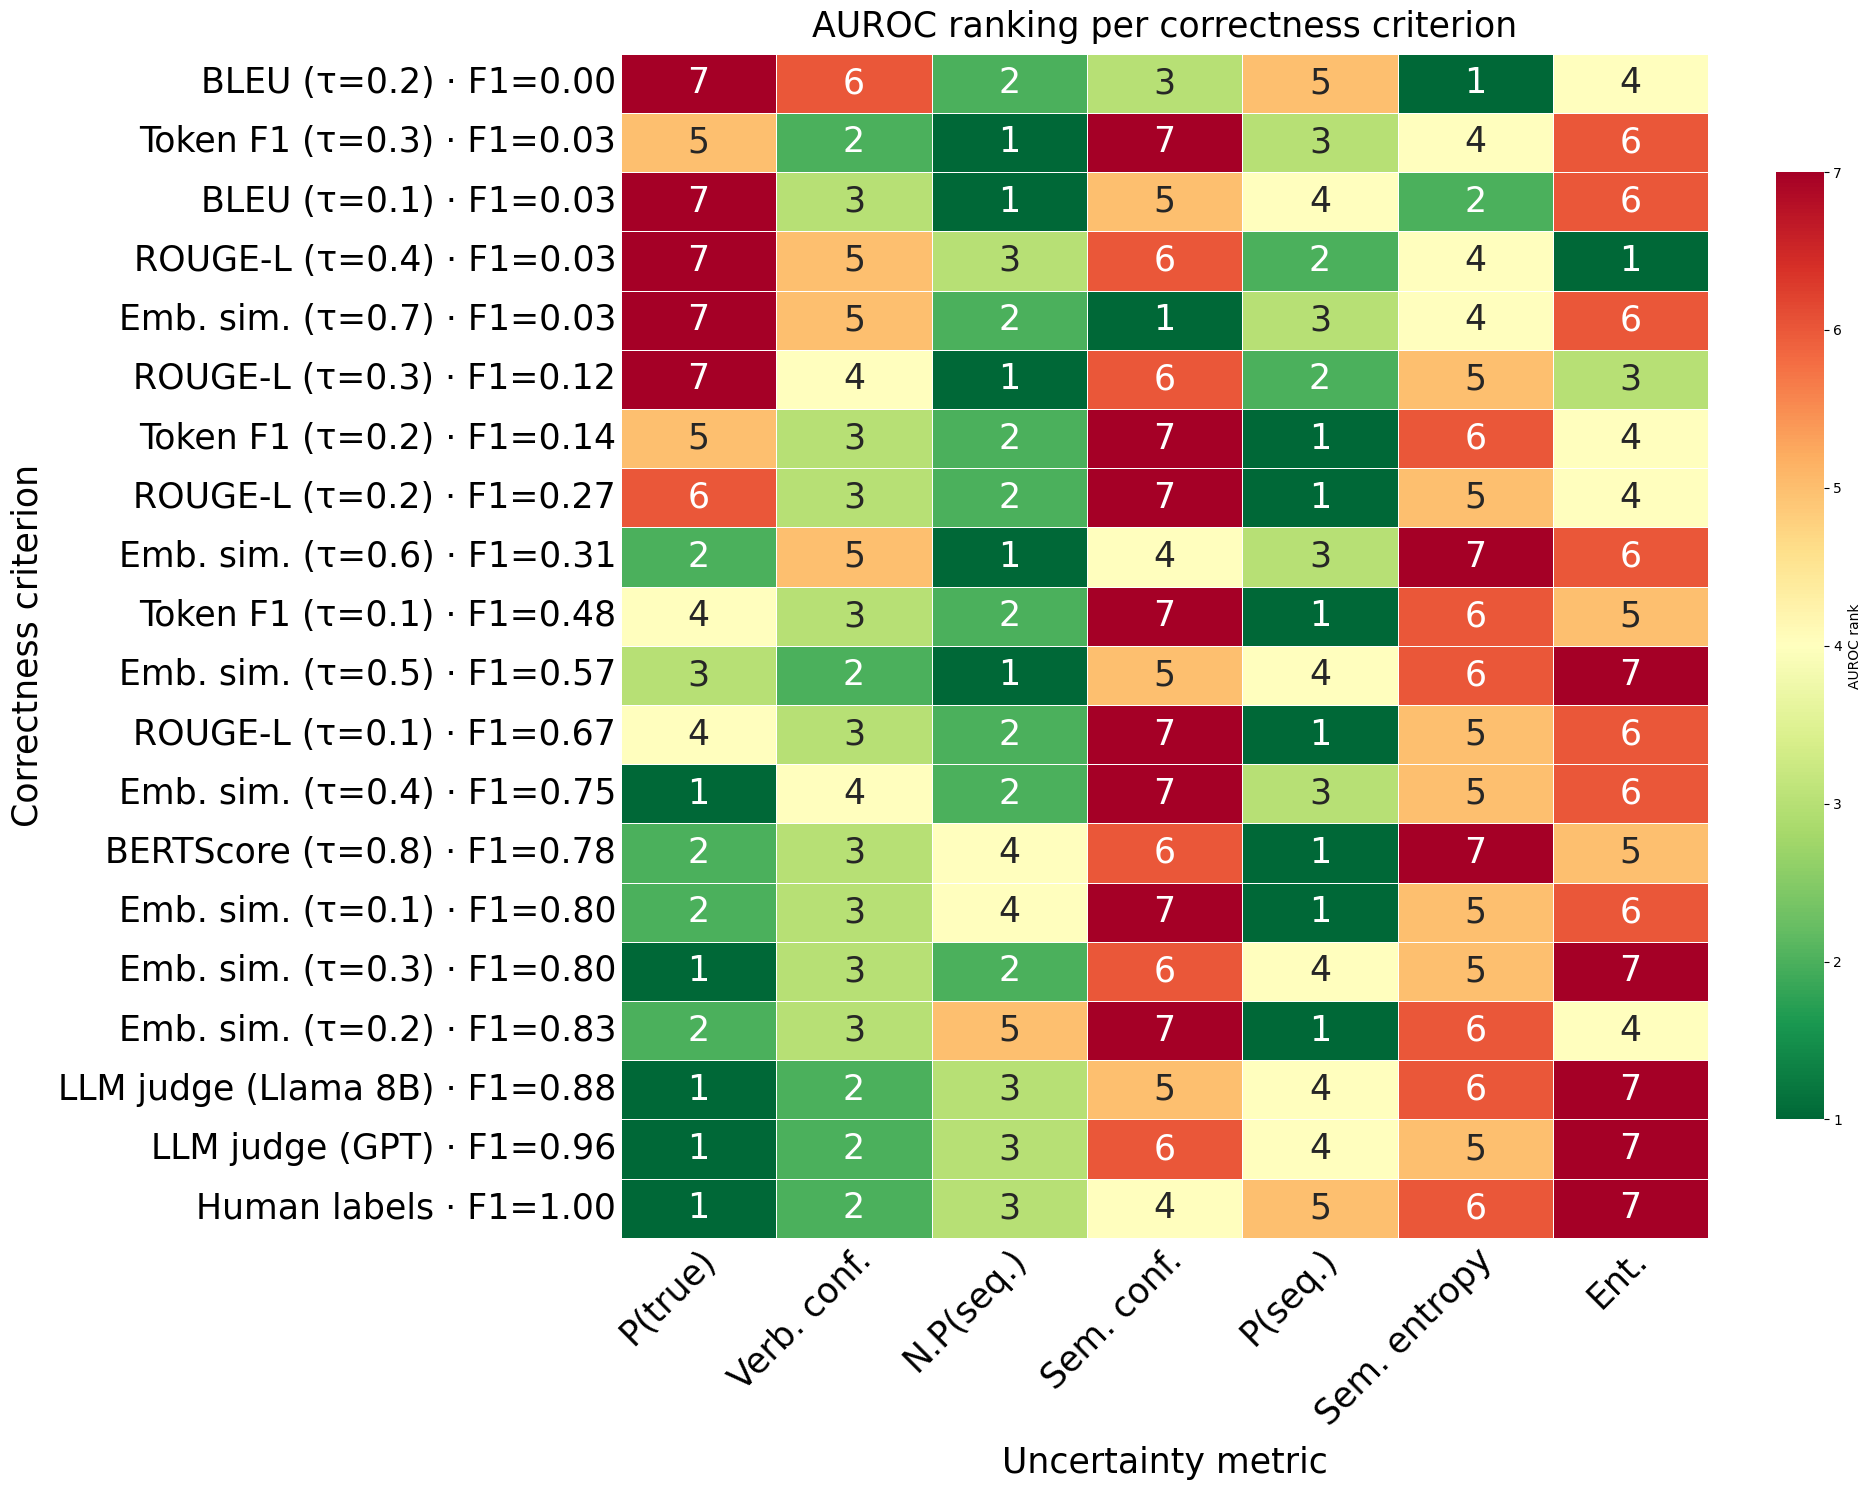

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_rank"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values().index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    annot_kws={"size": 25},
    cmap="RdYlGn_r",  # rank 1 = green, rank 7 = red
    vmin=1,
    vmax=7,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "AUROC rank", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title="AUROC ranking per correctness criterion",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/auroc_ranking_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

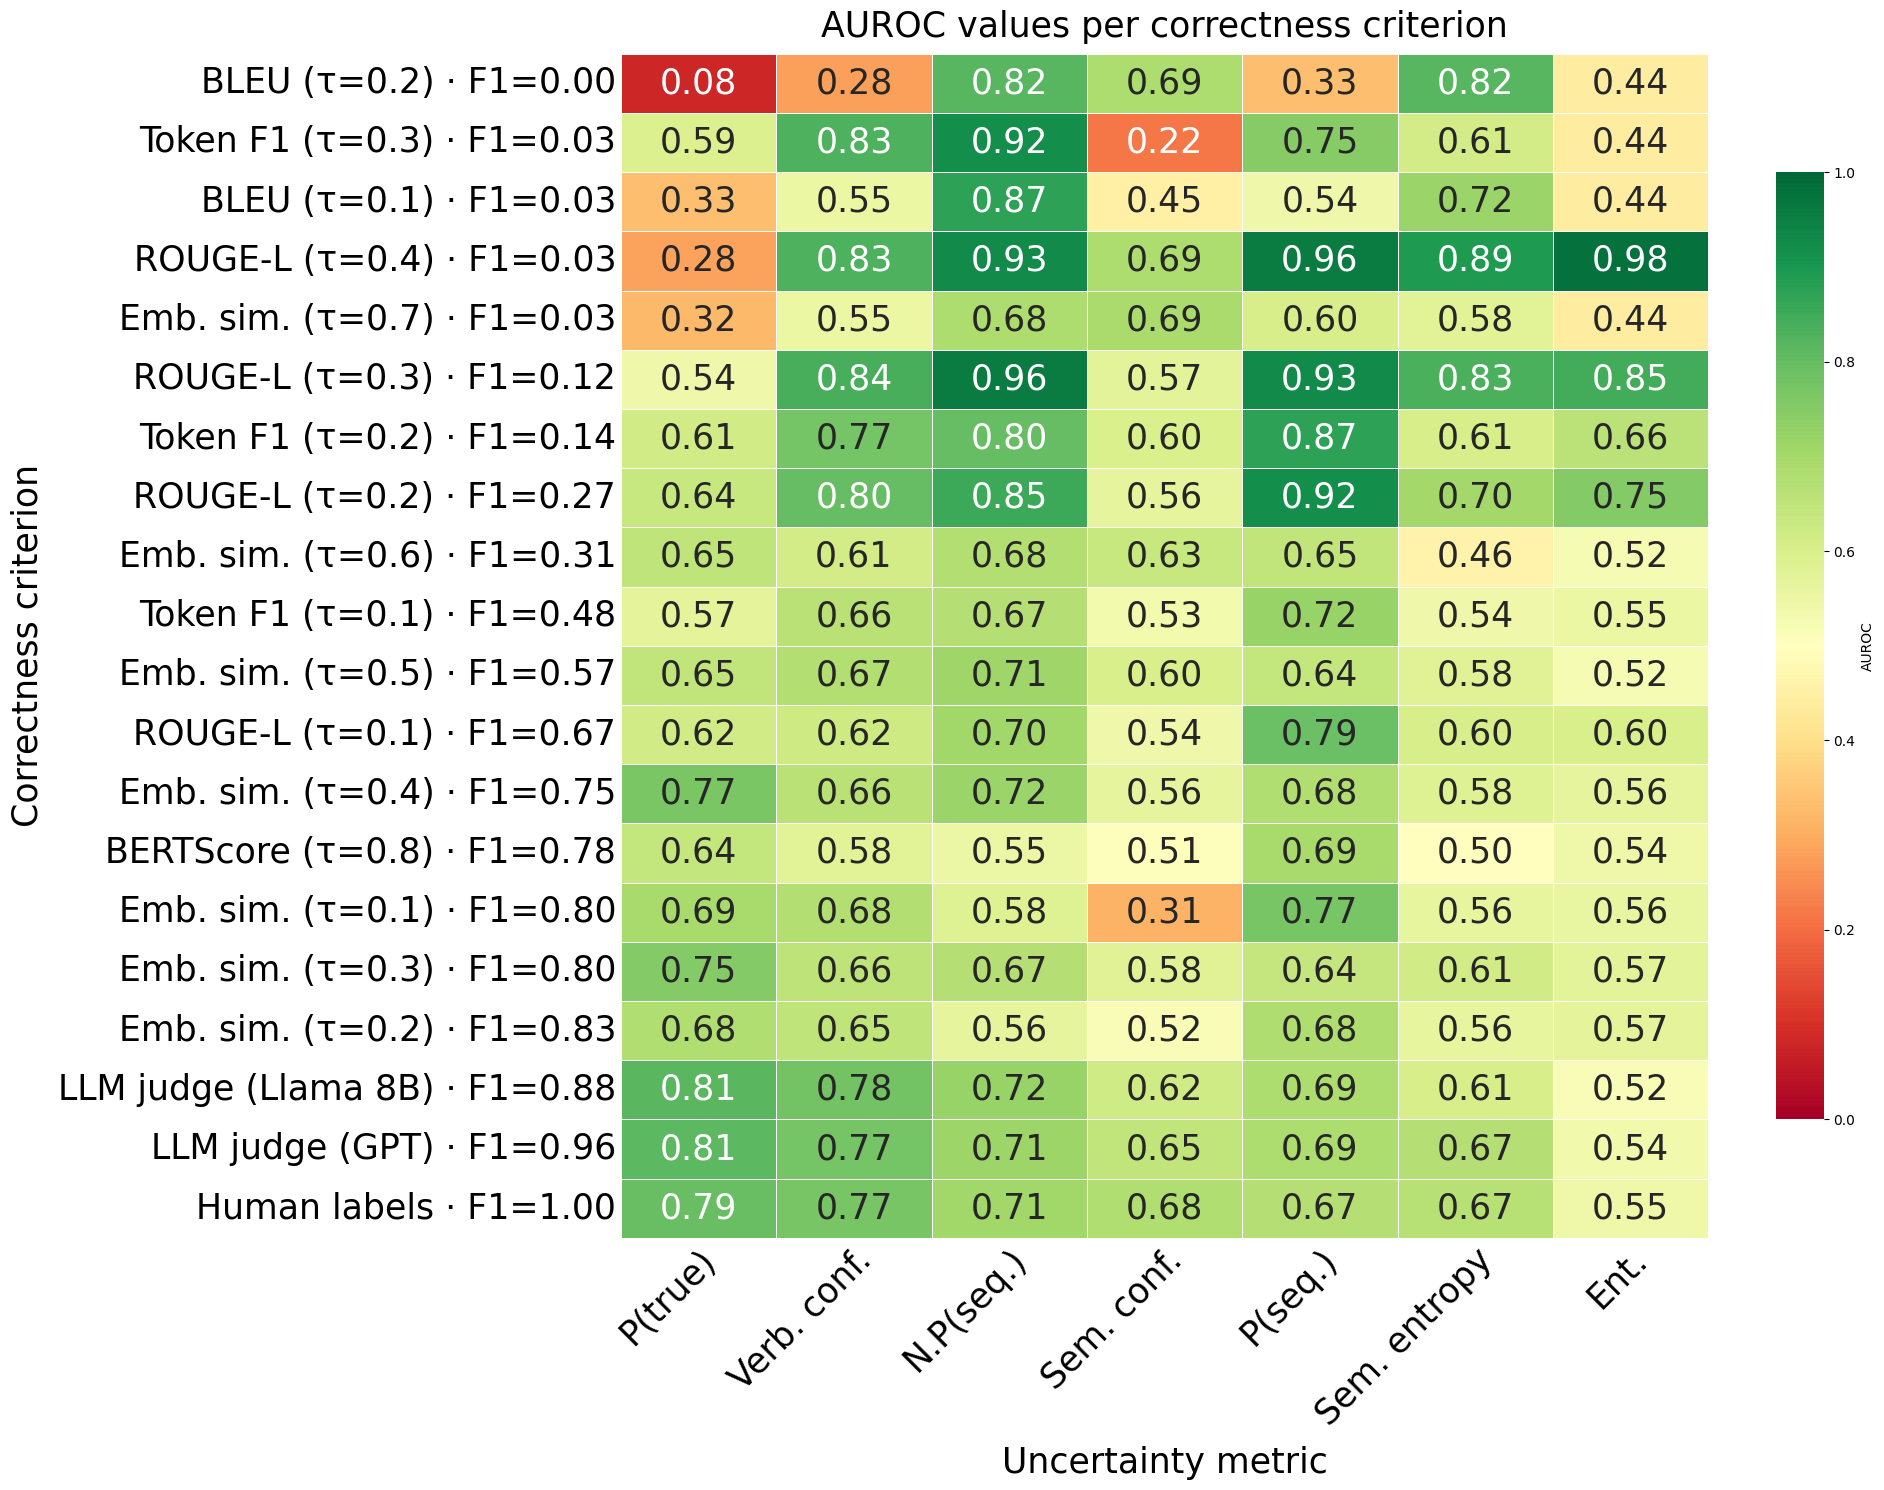

In [ ]:
heatmap_data = auroc_df.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc"
)
heatmap_data = heatmap_data.reindex(unique_correctness)
sorted_cols = heatmap_data.loc["manual"].sort_values(ascending=False).index
heatmap_data = heatmap_data[sorted_cols]
heatmap_data = label_heatmap_data(heatmap_data)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn",  # 0 = red, 1 = green
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "AUROC", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric",
    ylabel="Correctness criterion",
    title="AUROC values per correctness criterion",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/auroc_values_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()

In [60]:
# auroc_df[auroc_df["correctness"] == "manual"]

manual_map = (
    auroc_df[auroc_df["correctness"] == "manual"]
    .set_index("uncertainty_metric")["auroc"]
)

auroc_df["auroc_manual"] = auroc_df["uncertainty_metric"].map(manual_map)
auroc_df["auroc_diff"] = auroc_df["auroc"] - auroc_df["auroc_manual"]

In [61]:
auroc_df_filtered = auroc_df[auroc_df["correctness"] != "manual"]

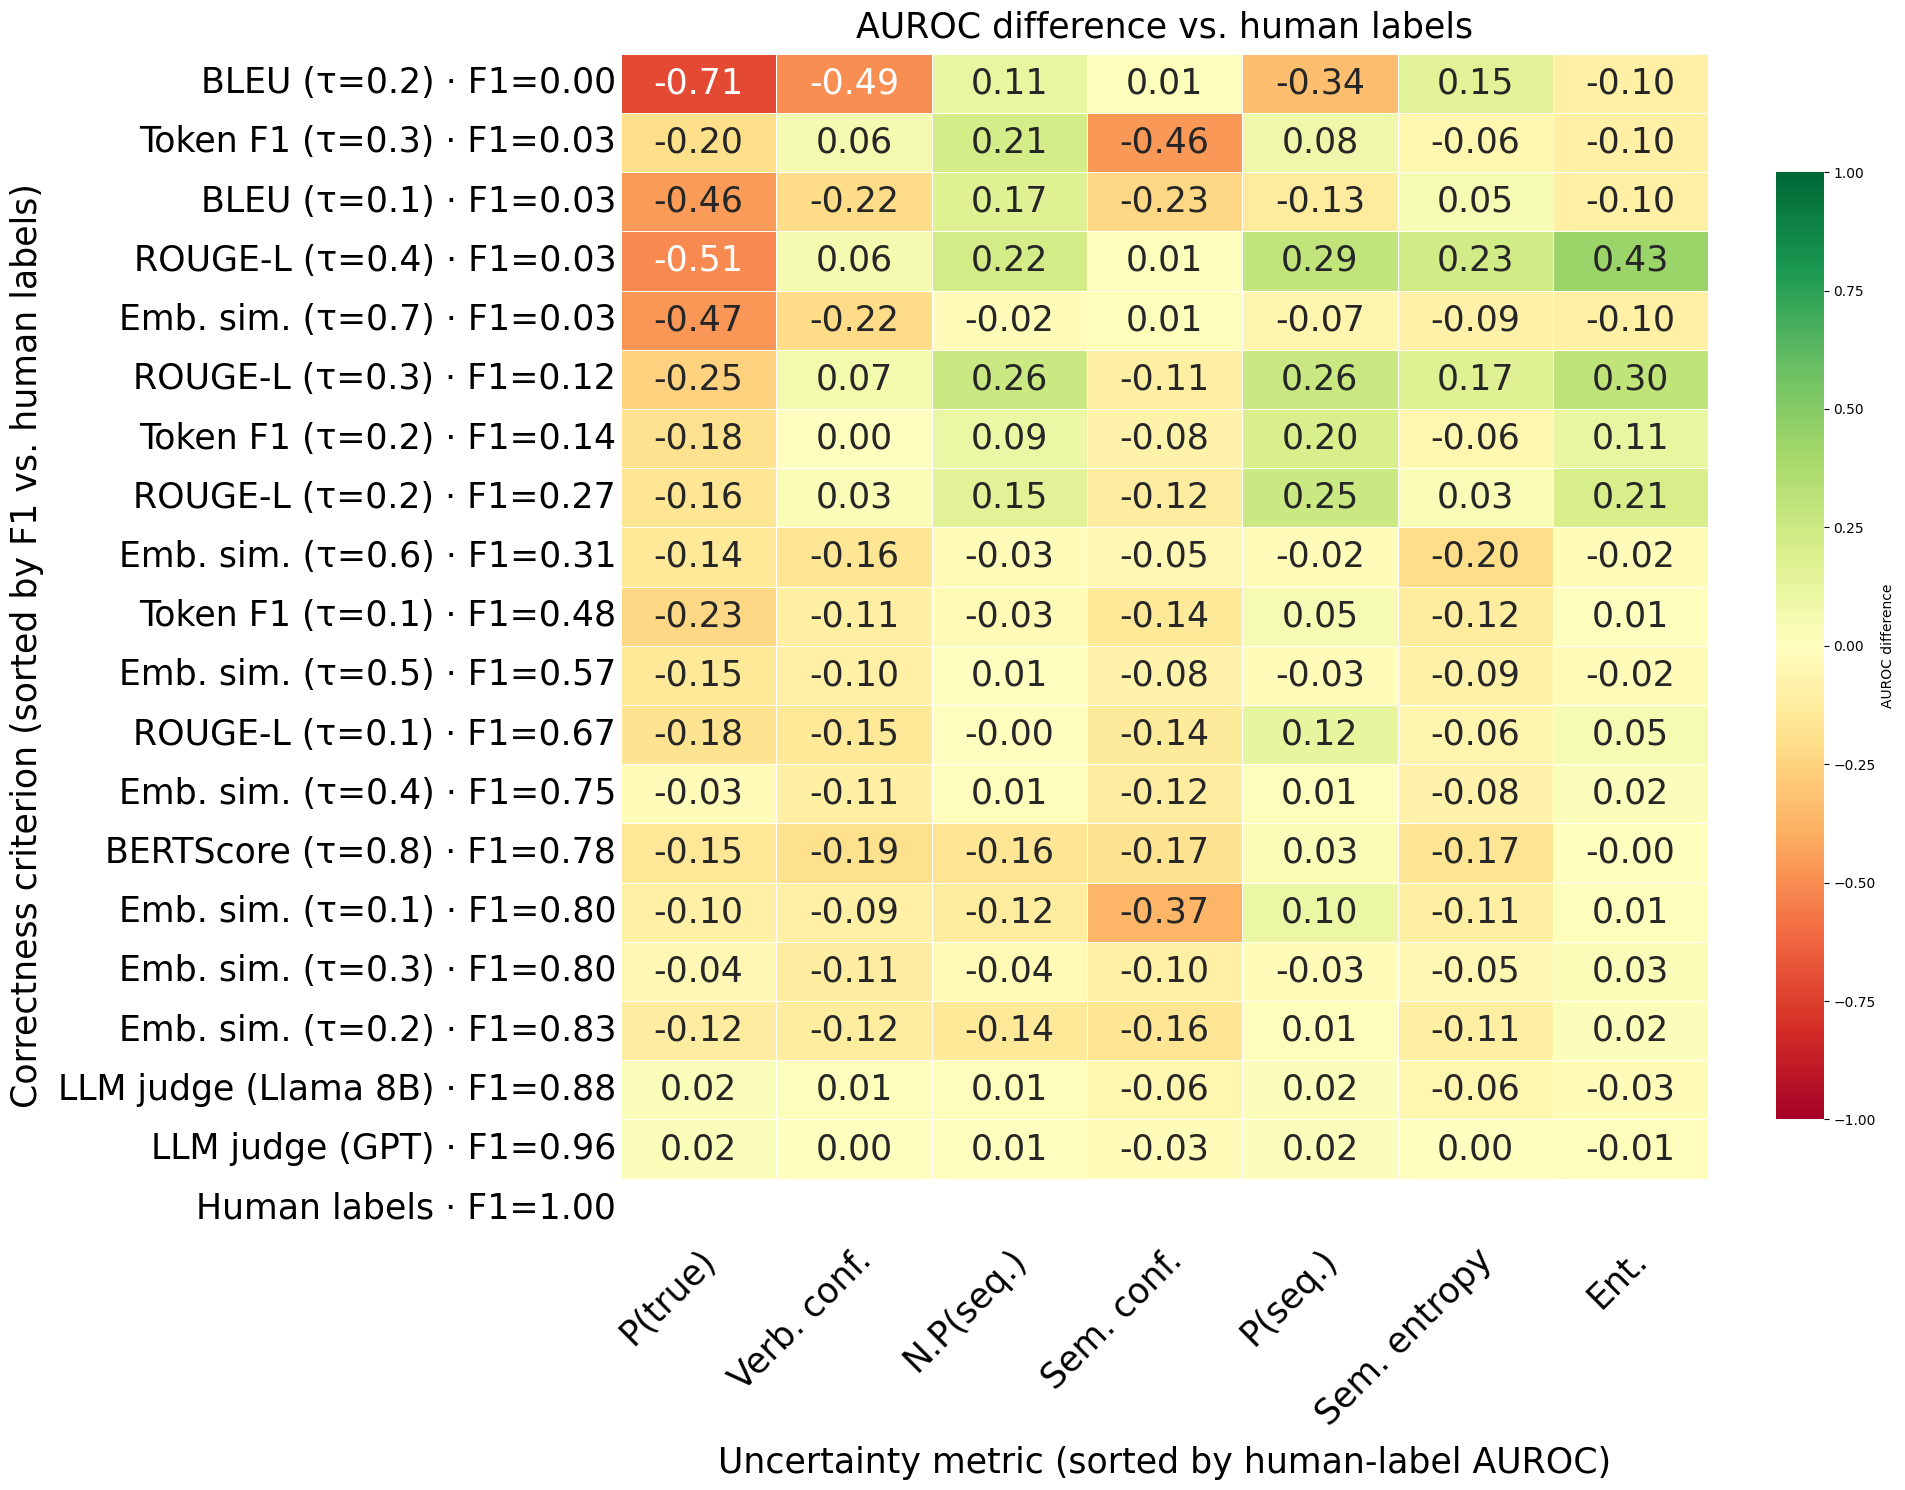

In [ ]:
heatmap_data_diff = auroc_df_filtered.pivot(
    index="correctness",
    columns="uncertainty_metric",
    values="auroc_diff"
)
heatmap_data_diff = heatmap_data_diff.reindex(unique_correctness)
heatmap_data_diff = heatmap_data_diff[sorted_cols]
heatmap_data_diff = label_heatmap_data(heatmap_data_diff)

plt.figure(figsize=(20, 15))

ax = sns.heatmap(
    heatmap_data_diff,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 25},
    cmap="RdYlGn",  # -1 = red, 1 = green
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "AUROC difference", "shrink": 0.8},
)

style_heatmap_axes(
    ax,
    xlabel="Uncertainty metric (sorted by human-label AUROC)",
    ylabel="Correctness criterion (sorted by F1 vs. human labels)",
    title="AUROC difference vs. human labels",
)

plt.tight_layout()
plt.savefig(
    f"/auroc_eval/results/plots/auroc_diff_per_correctness_{model_name}.pdf",
    bbox_inches="tight",
)
plt.show()